# **Distribution and Properties of Defects in Sewer Systems**

In [31]:
import sys
import os

sys.path.append(os.path.abspath(".."))
# Initialize global variables
import config as cfg

## Load data

In [58]:
from load_excel import load_multiple_sheets
from pathlib import Path

file_path = Path.cwd() / "Validated_data.xlsx"

df_information = load_multiple_sheets(
    file_path,
    sheet_names=["PIPES", "CCTV","DEFECTS","HYDRAULIC_PROPERTIES"],
    report=False #Shwo number of information uploaded
)

df_pipes = df_information.get("PIPES")
df_cctv = df_information.get("CCTV")
df_defects = df_information.get("DEFECTS")
df_hydraulic = df_information.get("HYDRAULIC_PROPERTIES")

## Data preparation

In [59]:
from data_preparation import merge_df_pipes_hydraulic, filter_by_material, build_material_color_map, validate_factors, classify_pipe_factors, merge_cctv_defects, create_defect_color_map, get_available_materials

### Calculate Defect-Length and Longitudinal Distance Normalized

In [60]:
from defect_length_calculation import build_defect_dataset

In [61]:
df_defects=build_defect_dataset(df_defects,df_cctv,df_pipes)

### Merge hydraulic properties with pipes

In [62]:
if df_hydraulic is not None:
    # Merge hydraulic properties only if available
    df_pipes = merge_df_pipes_hydraulic(df_pipes, df_hydraulic)

### Select materials for analysis

In [63]:
# Step 1: Show available materials
available_materials = get_available_materials(df_pipes)

# Step 2: User defines selection
cfg.selected_materials = ['AC', 'CONC', 'VC']  # example

#Step 3: Filter pipes by selected material
df_pipes_filtered = filter_by_material(df_pipes)


Available materials in dataset:
- AC
- CI
- CLS
- CONC
- FRP
- MS
- PE
- PVC-U
- SS
- VC

✅ Materials used for filtering:
   - AC
   - CONC
   - VC

Pipes selected: 794


### Create color map for selected materials

In [64]:
# Default colors
cfg.colors_paper = {
    'VC':   '#299729',
    'AC':   '#FF6B4A',
    'PE':   '#84B3D6',
    'CONC': '#FFB347',
    'PVC-U':  '#9467bd',
}

# Set color map for materials
cfg.colors_materials = build_material_color_map()

### Select factors for analysis

In [65]:
#List of selected factors
cfg.factors = ['Material', 'Sewage_type', 'Sewer_category', 'Installation_year','Diameter', 'Pipe_length','Depth']
# Validate that the factors exist in the dataframes
cfg.factors = validate_factors(df_pipes_filtered)

The factors were successfully selected. Selected factors: ['Material', 'Sewage_type', 'Sewer_category', 'Installation_year', 'Diameter', 'Pipe_length', 'Depth']


### Classify factors into numerical and categorical

Automatic classification into numerical and categorical factors. If you want to change this classification manually, write the list of numerical factors in `numeric_factors_override` and the categorical ones in `categorical_factors_override`.

In [66]:
# Function to classify factors
cfg.factors_num, cfg.factors_cat = classify_pipe_factors(df_pipes, numeric_factors_override=None, categorical_factors_override=None)

Classification:
Numeric factors: ['Installation_year', 'Diameter', 'Pipe_length', 'Depth']
Categorical factors: ['Material', 'Sewage_type', 'Sewer_category']


### Merge pipes factors with cctv and defects dataframes

In [67]:
# Merge function
df_cctv_filtered, df_defects_filtered = merge_cctv_defects(df_cctv, df_pipes_filtered, df_defects)

### Create color map for defects

In [68]:
# Default color palette for defect codes
cfg.palette_defects_final = {
    'JF': '#08306b',
    'DP': '#08519c',
    'RI': '#2171b5',
    'ED': '#4292c6',
    'DG': '#6baed6',
    'CL': '#00441b',
    'LF': '#006d2c',
    'CM': '#238b45',
    'LX': '#41ae76',
    'CC': '#66c2a4',
    'DE': '#99d8c9',
    'JD': '#a63603',
    'OP': '#d94801',
    'LP': '#fd8d3c',
    'PF': '#feb24c',
    'SD': '#fdd49e',
    'JO': '#3f007d',
    'PH': '#54278f',
    'IP': '#6a51a3',
    'DF': '#807dba',
    'PB': '#67000d',
    'TM': '#a50f15',
    'BDE': '#cb181d',
    'EX': '#ef3b2c',
    'MHJ': '#fb6a4a',
    'OT': '#8c510a',
    'PL': '#bf812d',
    'PX': '#dfc27d',
    'SV': '#f6e8c3',
}

cfg.palette_defects_final = create_defect_color_map(df_defects, Defect_code_col="Defect_code")
# Add the category 'Others' to the list
if 'Others' not in cfg.palette_defects_final:
    cfg.palette_defects_final['Others'] = cfg.palette_defects_final.get('Others', '#999999')

## CCTV Dataset description

In [69]:
from dataset_description import combined_summary_two_tables, analyze_ecdf_by_material, plot_boxplots_grid, compute_ps_table

### Statistics summary table

In [70]:
# Create the summaries for numerical and categorical variables
summary_num, summary_cat = combined_summary_two_tables(df_cctv_filtered, df_pipes_filtered)
# Display the summaries
display(summary_num)
display(summary_cat)

,variable,dataset,count,mean,std,min,median,max
4,Installation_year,Network,752.0,1977.327128,27.875640,1903.00,1981.00,2021.00
5,Installation_year,CCTV,752.0,1977.327128,27.875640,1903.00,1981.00,2021.00
2,Diameter,Network,760.0,281.026316,165.488256,100.00,225.00,750.00
3,Diameter,CCTV,760.0,281.026316,165.488256,100.00,225.00,750.00
6,Pipe_length,Network,794.0,43.109219,27.384265,1.77,37.65,208.97
7,Pipe_length,CCTV,794.0,43.109219,27.384265,1.77,37.65,208.97
0,Depth,Network,119.0,1.990168,1.083091,0.23,1.73,8.17
1,Depth,CCTV,119.0,1.990168,1.083091,0.23,1.73,8.17


,variable,dataset,summary
0,Material,Network,"VC (35.1%), AC (34.4%), CONC (30.5%)"
1,Material,CCTV,"VC (35.1%), AC (34.4%), CONC (30.5%)"
2,Sewage_type,Network,"Waste (52.9%), Comb (47.1%)"
3,Sewage_type,CCTV,"Waste (52.9%), Comb (47.1%)"
4,Sewer_category,Network,"Local (53.0%), Transmission (47.0%)"
5,Sewer_category,CCTV,"Local (53.0%), Transmission (47.0%)"


### Sample Representativeness (CCTV and Pipes)

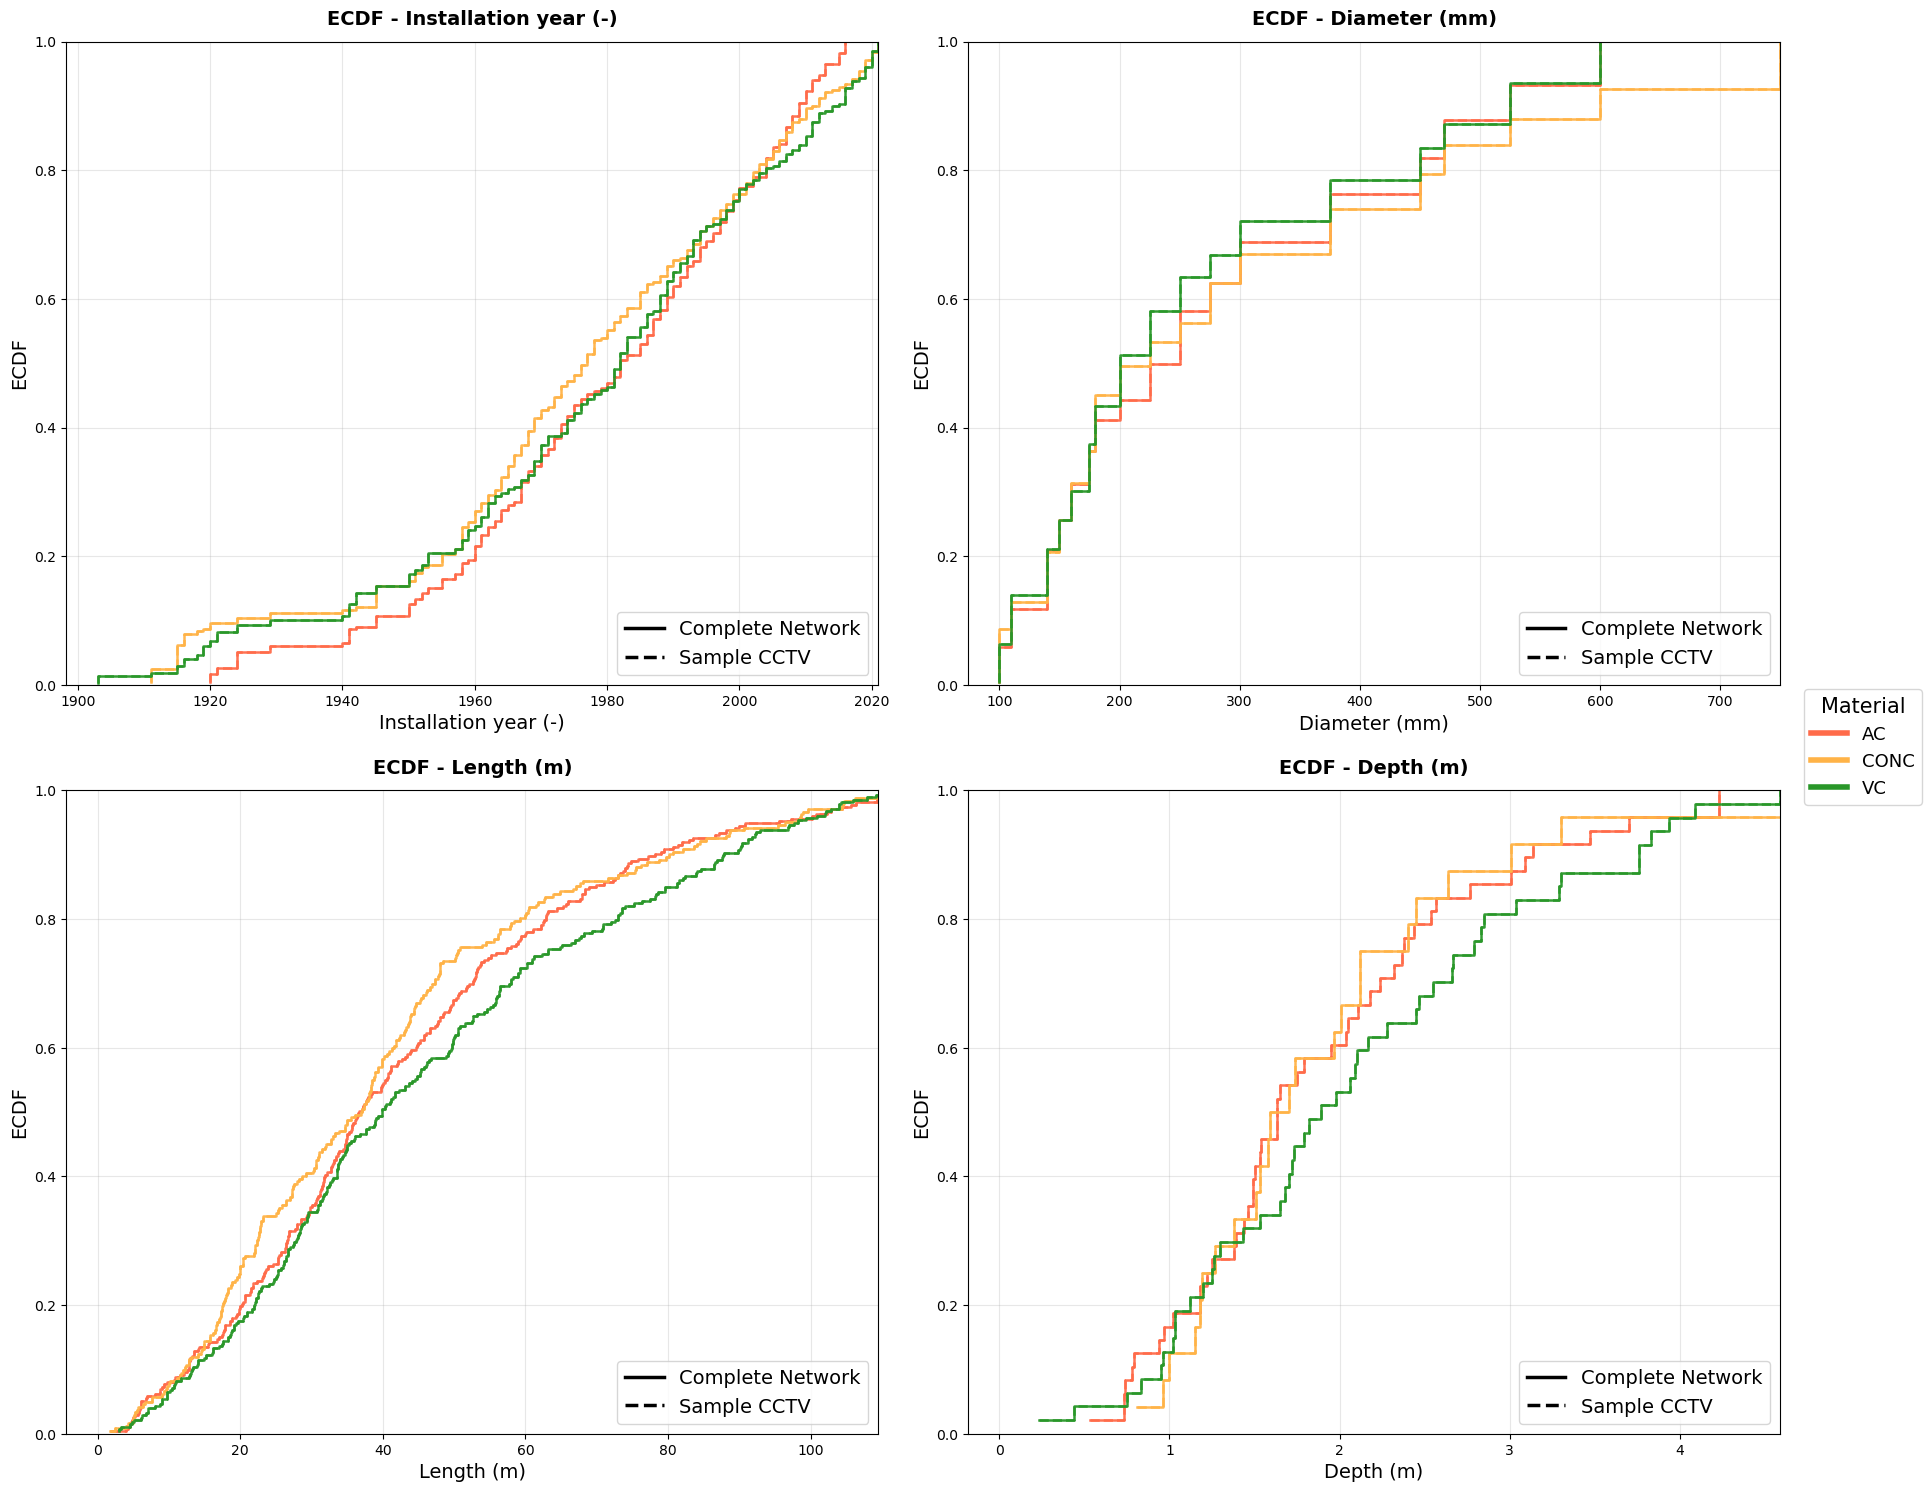

In [71]:
# Run the function
summary_table = analyze_ecdf_by_material(
    df_population=df_pipes_filtered,
    df_sample=df_cctv_filtered,
    material_col="Material"
)

# # Organize display results
# summary_table['Variable'] = pd.Categorical(
#     summary_table['Variable'],
#     ordered=True
# )
summary_table = summary_table.sort_values('Variable')

In [72]:
compute_ps_table(df_population=df_pipes_filtered,
    df_sample=df_cctv_filtered,material_col='Material',numeric_cols=cfg.factors_num,materials=cfg.selected_materials)

Material,AC,CONC,VC
Variable,,,
Average Depth,0.5,0.5,0.5
Diameter,0.5,0.5,0.5
Installation Year,0.5,0.5,0.5
Length,0.5,0.5,0.5


### Description of pipes with CCTV inspection (Boxplots)

C:\Users\mgon869\OneDrive - The University of Auckland\1.PhD\7. Watercare\13. Code_PhD_Repository\3.Defects_description\dataset_description.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mgon869\OneDrive - The University of Auckland\1.PhD\7. Watercare\13. Code_PhD_Repository\3.Defects_description\dataset_description.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mgon869\OneDrive - The University of Auckland\1.PhD\7. Watercare\13. Code_PhD_Repository\3.Defects_description\dataset_description.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

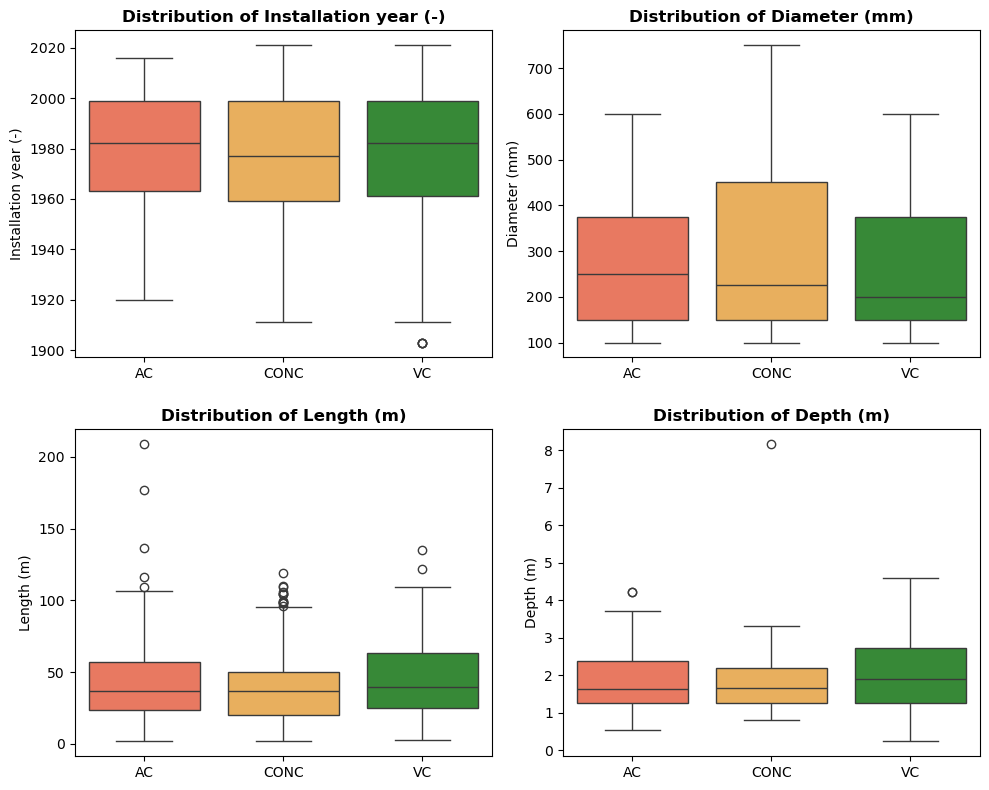

In [73]:
plot_boxplots_grid(df_cctv_filtered, [col for col in cfg.factors_num if col != 'Dry_peak_flow_rate'], group_col="Material")

## Defect description

In [74]:
from defect_general_description import plot_defect_counts_per_pipe, plot_defects_stacked_with_others

### Defect density (Number of defects per pipe)

C:\Users\mgon869\OneDrive - The University of Auckland\1.PhD\7. Watercare\13. Code_PhD_Repository\3.Defects_description\defect_general_description.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


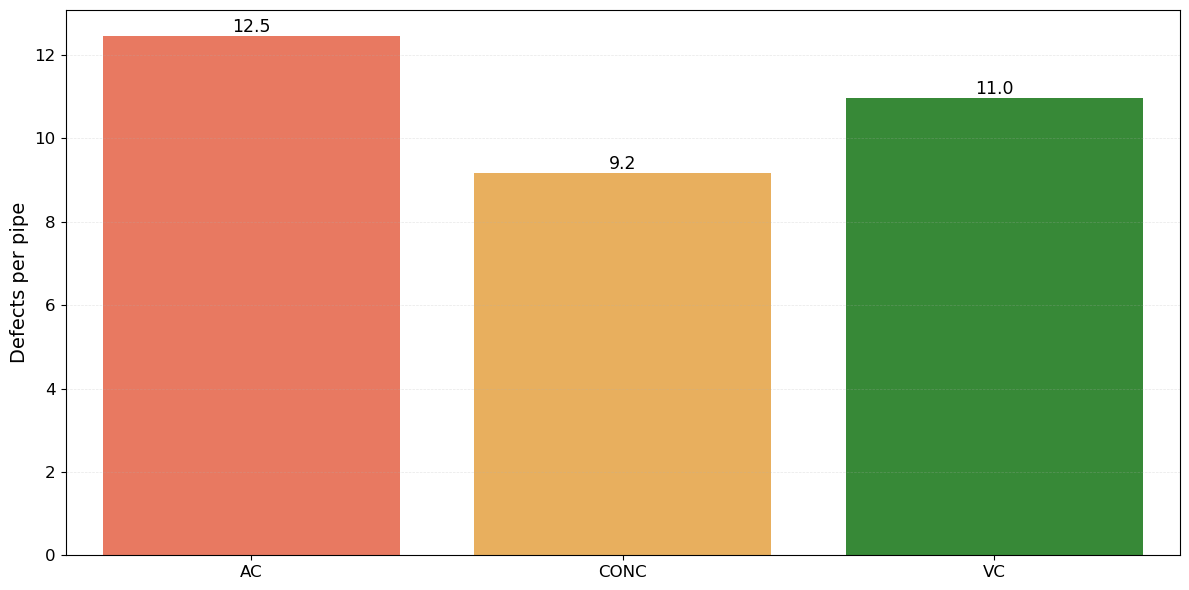

<Axes: ylabel='Defects per pipe'>

In [75]:
# Plot figure
plot_defect_counts_per_pipe(
    df_defects=df_defects_filtered,
)

### Distribution of defects type

**Table of Defect Types**

To understand the characteristics and different types of defects, the following table provides a summary of defect codes, their descriptions, and the related properties.

| Code | Defect name | Description | SZ. | E. | C.L. |
|:-----|:-------------|:-------------|:---:|:--:|:----:|
| CC | Cracking Circumferential | Cracking at right angles to the pipe axis. |  X  |    |  X   |
| CL | Cracking Longitudinal | Cracking parallel to the pipe axis. |  X  | X  |  X   |
| CM | Cracking Multiple | Cracking in multiple directions. |  X  | X  |  X   |
| DE | Debris Silty | Deposits of silt, sand, mud, or gravel in the pipe. |  X  | X  |      |
| DF | Deformed Pipe | Deformation in rigid pipe. |  X  | X  |  X   |
| DG | Debris Greasy | Fat, scale, and other adhering material. |  X  | X  |  X   |
| DP | Dipped Pipe | Sag in the pipe causing water to pond. |  X  | X  |      |
| ED | Encrustation Deposits | Deposits from evaporated groundwater with dissolved salts/minerals. |  X  | X  |  X   |
| EX | Exfiltration | Visible flow of water out of the pipe. |  X  |    |  X   |
| IP | Infiltration Present | Visible infiltration through a pipe defect. |  X  |    |  X   |
| JD | Joint Displaced | Pipe segments have a vertical or horizontal displacement relative to each other. |  X  |    |  X   |
| JF | Joint Faulty | Sealing or physical joint defects. |  X  |    |  X   |
| JO | Joint Open | Pipe segments are displaced longitudinally. |  X  |    |  X   |
| LF | Lateral Faulty | Joint sealing defects or physical damage to lateral connections. |  X  |    |  X   |
| LP | Lateral Protruding | Pipe is protruding into the inspected pipe. |  X  |    |  X   |
| LX | Lateral Problem | Defects in the lateral pipe. |  X  |    |  X   |
| MHJ | Manhole Joint Faulty | The bond between the pipe and manhole is faulty. |     |    |  X   |
| OP | Obstruction Permanent | Fixed object causing obstruction. |  X  |    |  X   |
| OT | Obstruction Temporary | Potentially removable obstruction. |  X  |    |  X   |
| PB | Pipe Broken | Pipe broken into blocks by cracks forming a mosaic pattern. |  X  | X  |  X   |
| PF | Deformed Plastic Pipe | Deformation in plastic pipe. |  X  | X  |  X   |
| PH | Pipe Holed | Hole made in the pipe. |  X  | X  |  X   |
| PL | Protective Lining Defective | The lining of a pipe is defective. |  X  | X  |  X   |
| RI | Root Intrusion | Tree roots entering the pipe through a defect. |  X  |    |  X   |
| SD | Surface Damage | Damage in the inside surface of the pipe. |  X  | X  |  X   |
| SV | Soil Visible | The soil is visible through a defect. |     | X  |  X   |
| TM | Tomo | Cavity outside the pipe is visible through a defect. |     | X  |  X   |


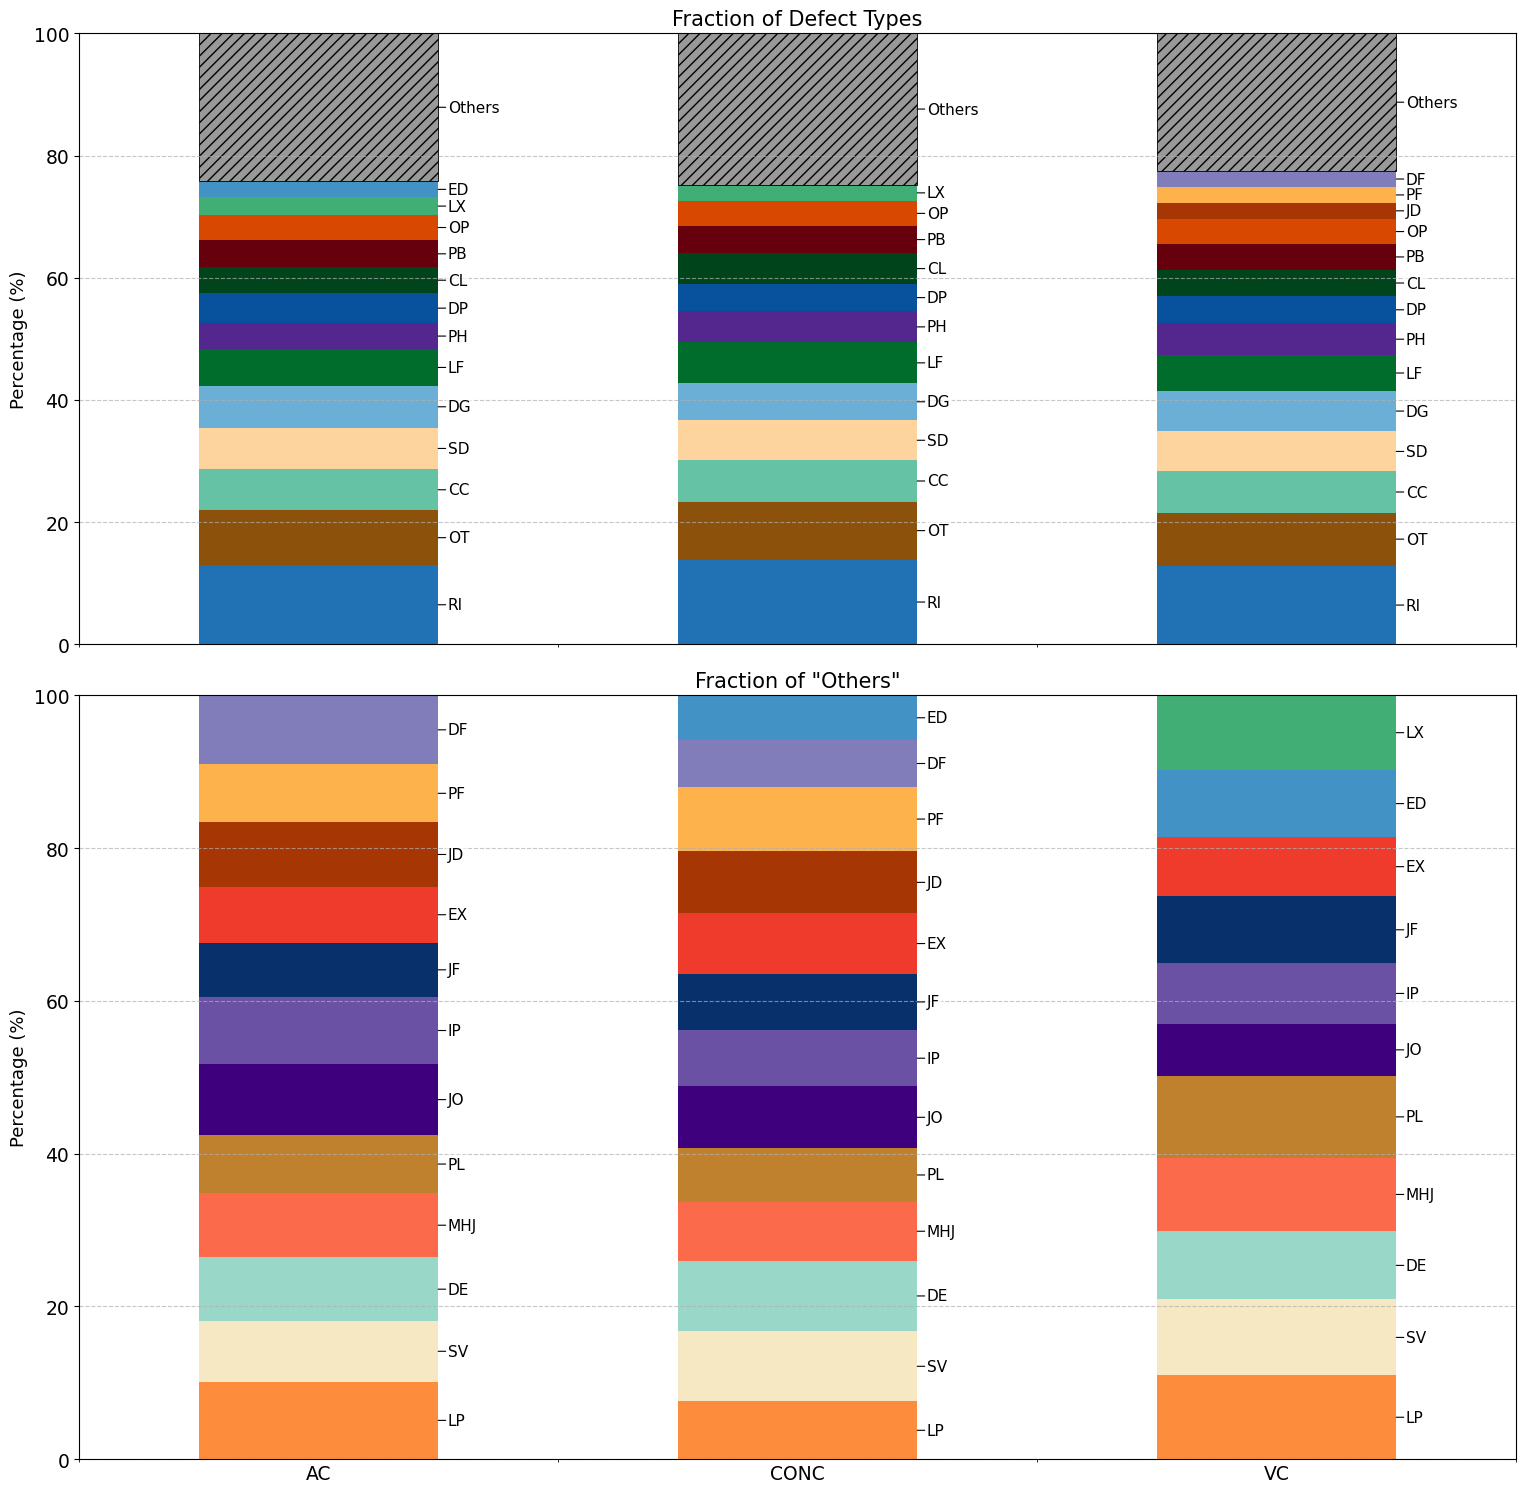

In [50]:
plot_defects_stacked_with_others(df_defects_filtered,threshold=2.5, color=cfg.palette_defects_final)

### Defect properties description

In [51]:
from defect_properties_description import plot_defect_size_bars, plot_defect_heatmaps_longitudinal, plot_defect_density_extent_horizontal, plot_defect_position_heatmaps

#### Size

C:\Users\mgon869\OneDrive - The University of Auckland\1.PhD\7. Watercare\13. Code_PhD_Repository\3.Defects_description\defect_properties_description.py:215: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0.06, 0, 1, 0.98])


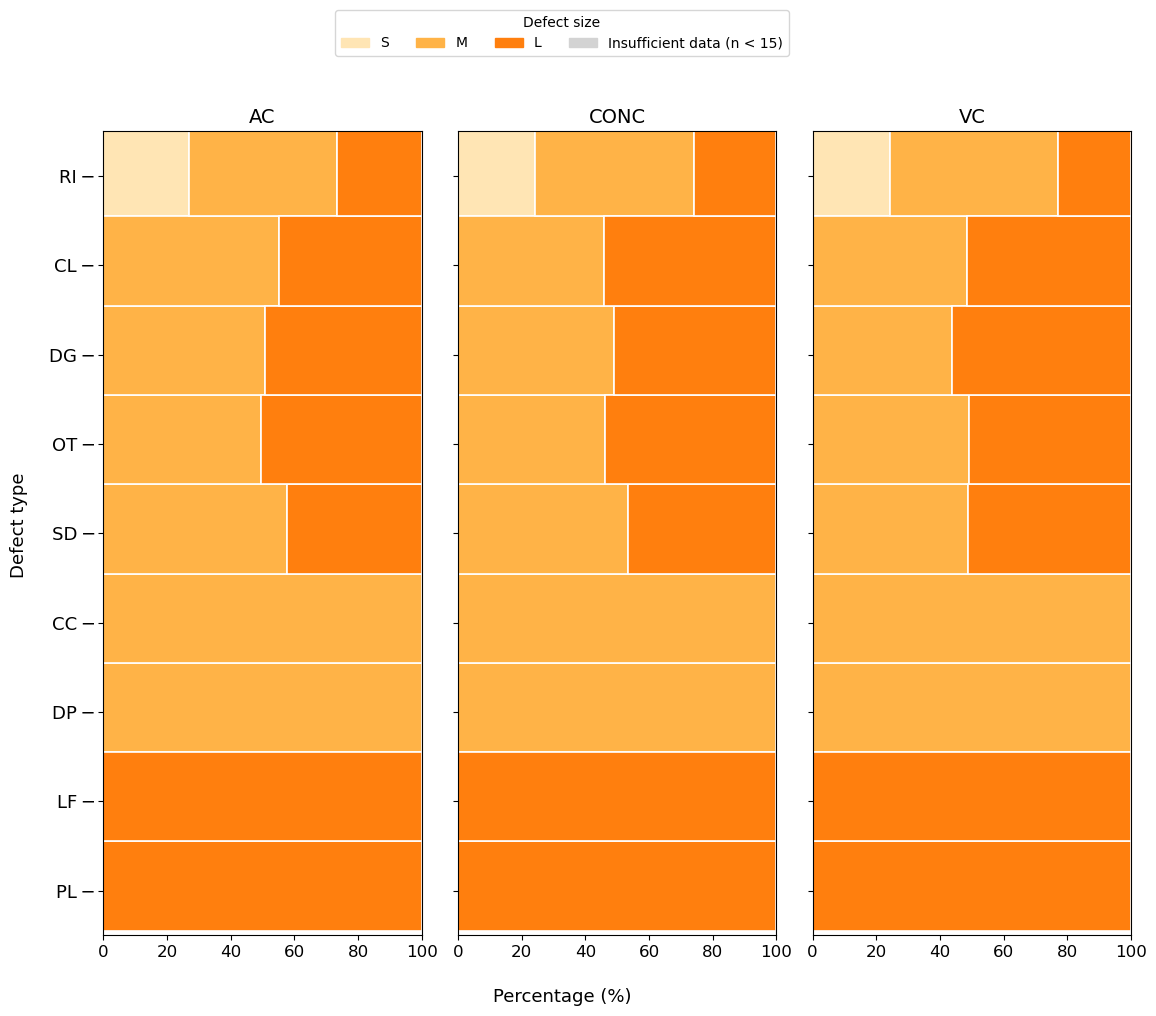

In [52]:
#Plot defect size distribution per material
plot_defect_size_bars(df=df_defects_filtered, min_count = 15, valid_sizes=['S','M','L'])

#### Longitudinal distance

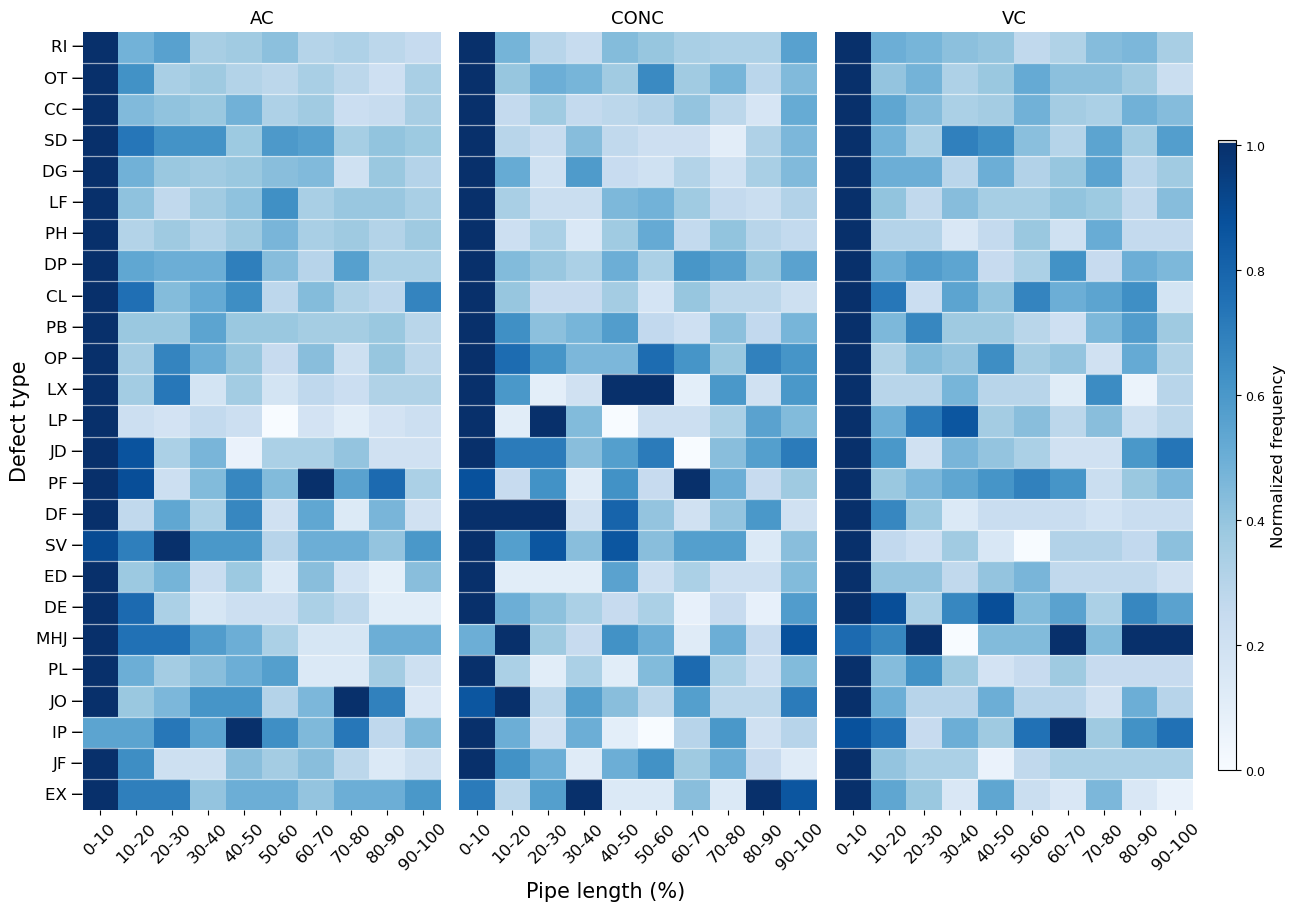

In [53]:
plot_defect_heatmaps_longitudinal(df_defects_filtered,min_count=15)

#### Extent

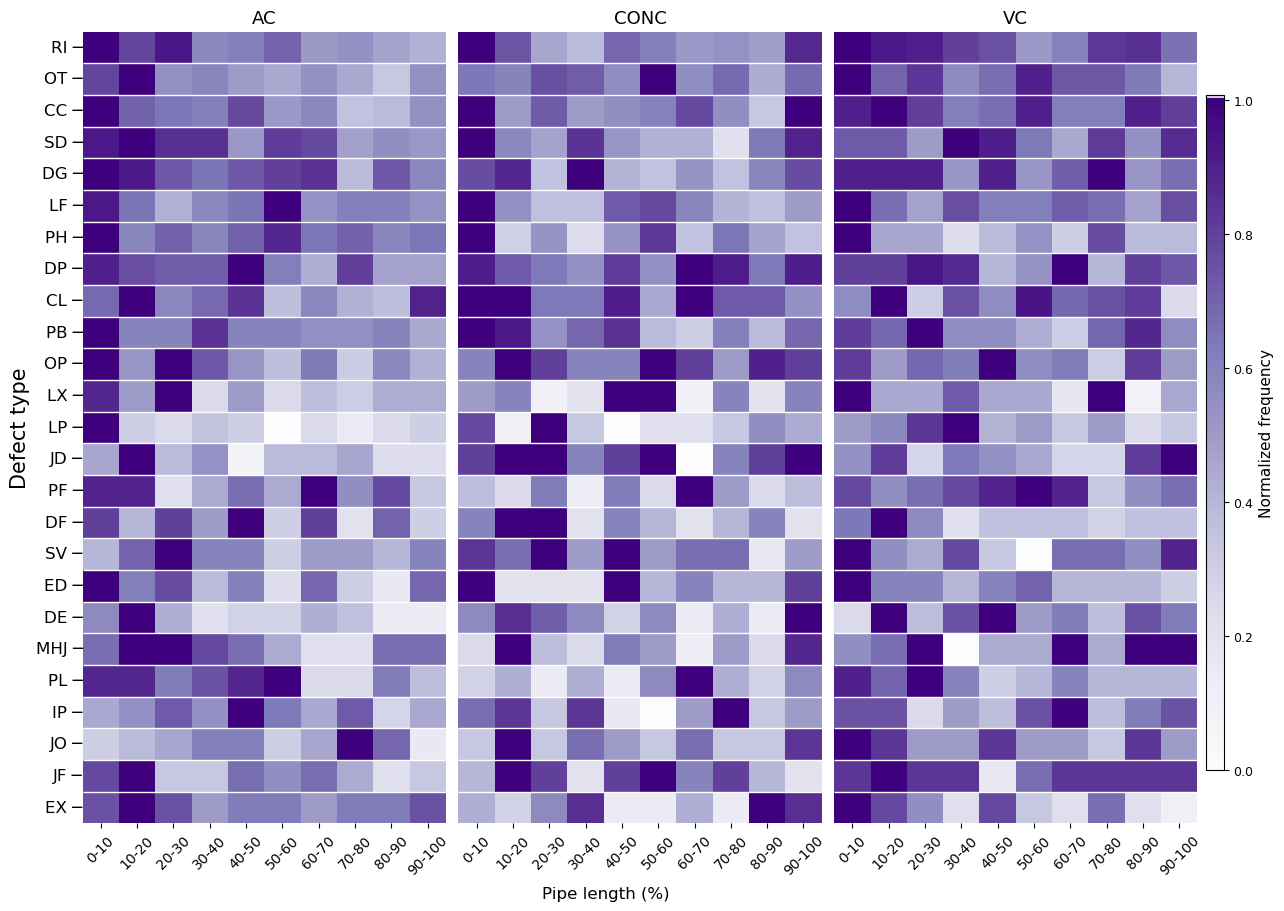

In [54]:
plot_defect_density_extent_horizontal(df_defects_filtered,min_count=15)

#### Clock reference position

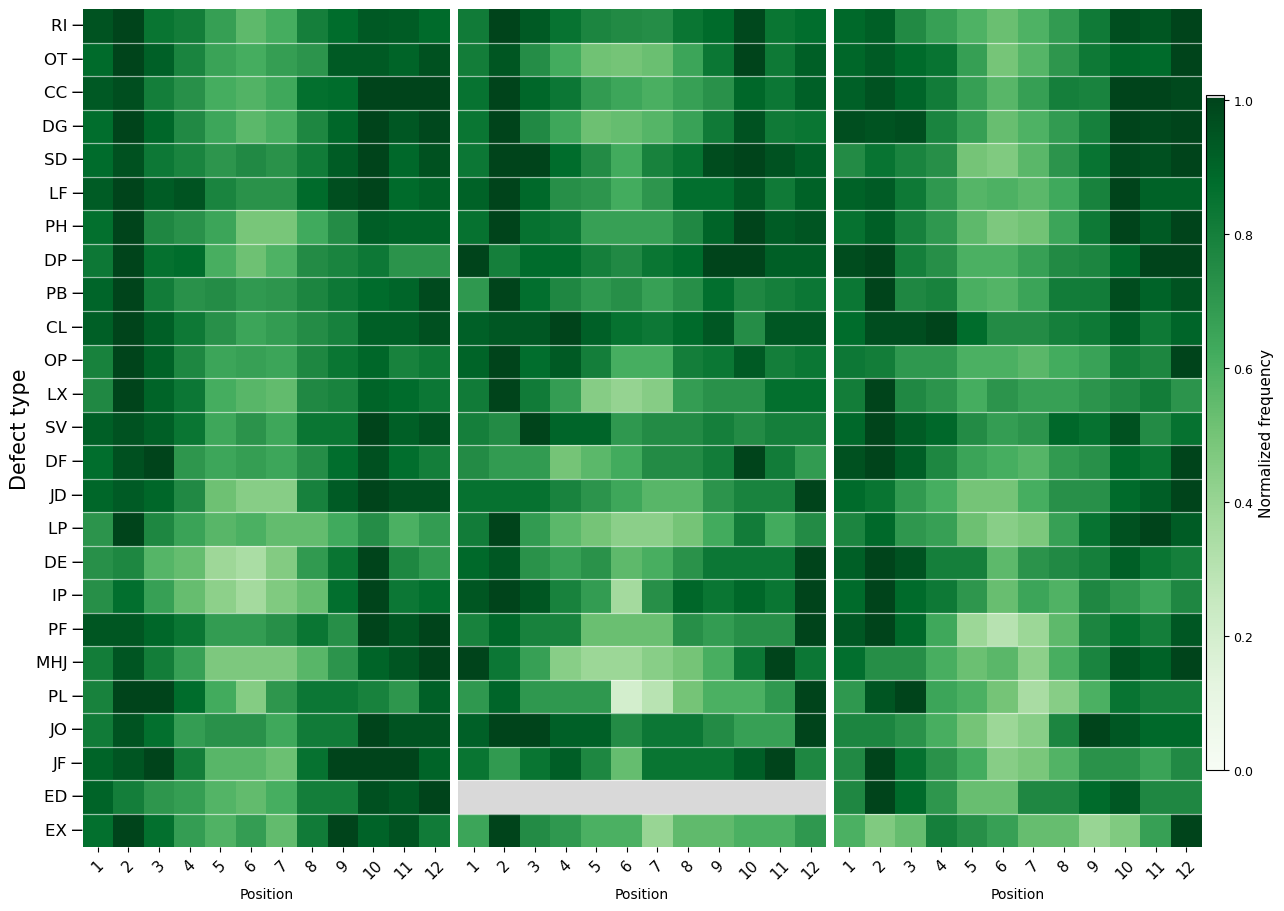

In [55]:
plot_defect_position_heatmaps(df=df_defects_filtered, min_count = 15)

### Defect correlation

In [56]:
from defect_correlation import plot_defect_type_correlation

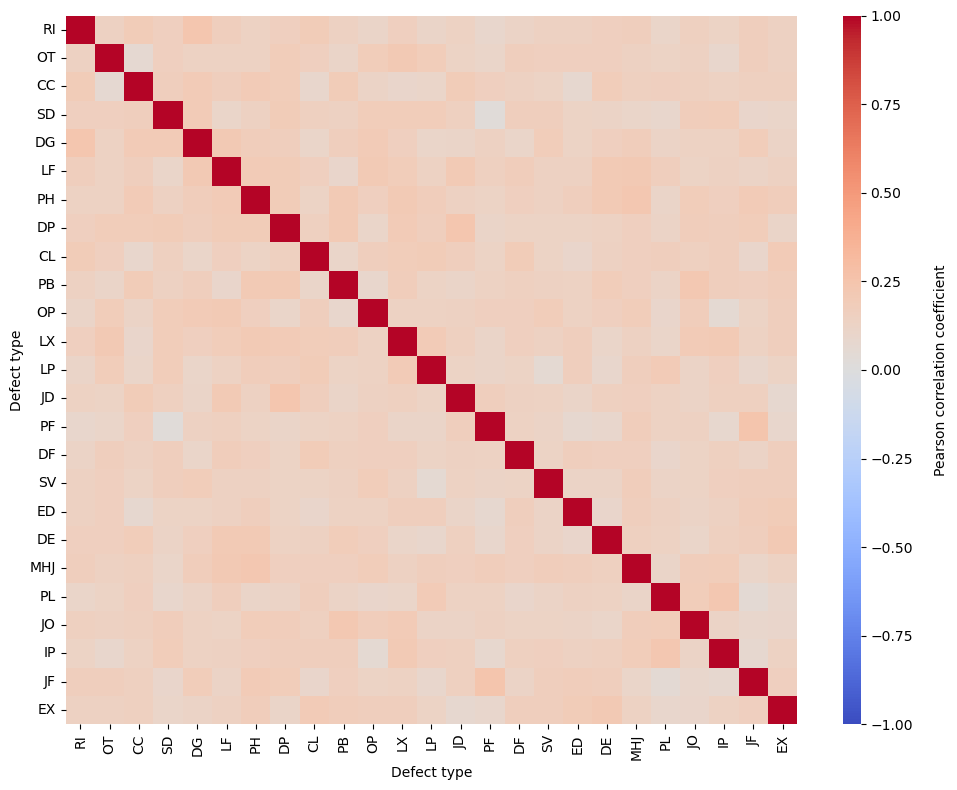

In [57]:
plot_defect_type_correlation(df_defects_filtered)